###  Tarea  2 Análisis Exploratorio e Inferencial

Estudiante: Ivan Ramiro Quiroga Castañeda


### Paso 2

### 2.1 Teorema Central del Límite (TCL) 

Media de las medias muestrales: 99.09
Desviación estándar de las medias muestrales: 8.87


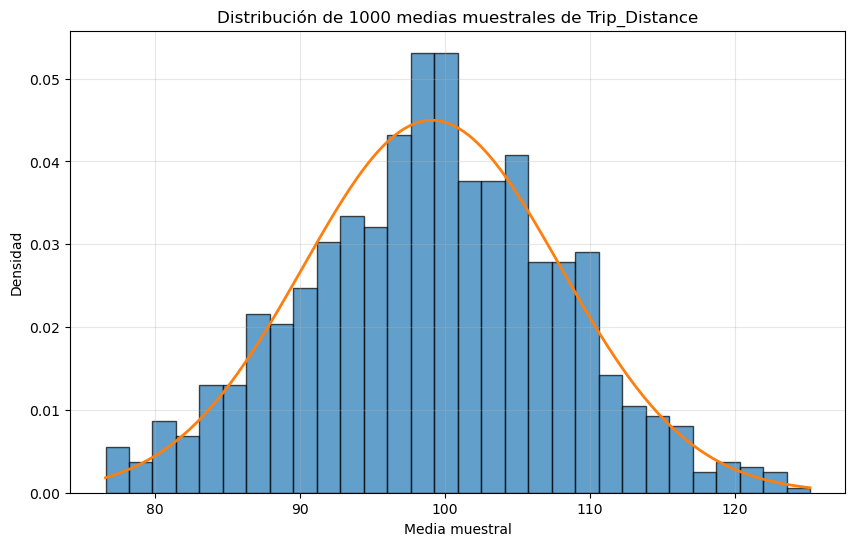

In [16]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from scipy.stats import norm
from statsmodels.stats.proportion import proportion_confint
from statsmodels.stats.proportion import proportion_confint, proportions_ztest
from statsmodels.stats.power import TTestIndPower

# Cargar datos
df = pd.read_csv("Anexo 1 - Base de Datos dynamic_pricing.csv")

# Crear variables solicitadas en la guía
df["Trip_Distance"] = df["Expected_Ride_Duration"]
df["Trip_Rating"] = df["Average_Ratings"]

# Parámetros de simulación
n = 30
repeticiones = 1000
np.random.seed(123)

datos = df["Trip_Distance"].dropna().values

# Simulación de medias muestrales
medias_muestrales = np.array([
    np.mean(np.random.choice(datos, size=n, replace=True))
    for _ in range(repeticiones)
])

# Resultados numéricos
print("Media de las medias muestrales:", round(medias_muestrales.mean(), 2))
print("Desviación estándar de las medias muestrales:", round(medias_muestrales.std(ddof=1), 2))

# Gráfico
plt.figure(figsize=(10,6))
plt.hist(medias_muestrales, bins=30, density=True, alpha=0.7, edgecolor="black")

x = np.linspace(medias_muestrales.min(), medias_muestrales.max(), 300)
plt.plot(x, norm.pdf(x, medias_muestrales.mean(), medias_muestrales.std(ddof=1)), linewidth=2)

plt.title("Distribución de 1000 medias muestrales de Trip_Distance")
plt.xlabel("Media muestral")
plt.ylabel("Densidad")
plt.grid(alpha=0.3)
plt.show()

### 2.2 Intervalos de Confianza (IC) Calcula e interpreta

In [17]:

# 1. IC para la media

x = df["Trip_Distance"].dropna()
n = len(x)
media = np.mean(x)
desv = np.std(x, ddof=1)
alpha = 0.05

t_crit = stats.t.ppf(1 - alpha/2, df=n-1)
margen = t_crit * (desv / np.sqrt(n))
ic_media = (media - margen, media + margen)

print("IC 95% para la media de Trip_Distance:", ic_media)

# 2. IC para la proporción

rating_alto = (df["Trip_Rating"] >= 4).astype(int)
exitos = rating_alto.sum()
n_total = rating_alto.count()
proporcion = exitos / n_total

ic_prop = proportion_confint(count=exitos, nobs=n_total, alpha=0.05, method="normal")

print("Proporción muestral de Trip_Rating >= 4:", proporcion)
print("IC 95% para la proporción:", ic_prop)

# 3. IC para la varianza

var_muestral = np.var(x, ddof=1)

chi2_inf = stats.chi2.ppf(alpha/2, df=n-1)
chi2_sup = stats.chi2.ppf(1 - alpha/2, df=n-1)

ic_var = ((n-1)*var_muestral/chi2_sup, (n-1)*var_muestral/chi2_inf)

print("Varianza muestral de Trip_Distance:", var_muestral)
print("IC 95% para la varianza:", ic_var)

IC 95% para la media de Trip_Distance: (96.53705344080343, 102.63894655919655)
Proporción muestral de Trip_Rating >= 4: 0.686
IC 95% para la proporción: (0.6572342982735899, 0.7147657017264102)
Varianza muestral de Trip_Distance: 2417.2414974975
IC 95% para la varianza: (2218.5144202448337, 2644.0617720656383)


### 2.3 Pruebas de Hipótesis 

In [18]:
# Prueba t para comparar Trip_Distance entre Gold y Regular

grupo_gold = df[df["Customer_Loyalty_Status"] == "Gold"]["Trip_Distance"].dropna()
grupo_regular = df[df["Customer_Loyalty_Status"] == "Regular"]["Trip_Distance"].dropna()

t_stat, p_valor = stats.ttest_ind(grupo_gold, grupo_regular, equal_var=False)

print("Media Gold:", round(grupo_gold.mean(), 4))
print("Media Regular:", round(grupo_regular.mean(), 4))
print("Estadístico t:", round(t_stat, 4))
print("Valor p:", round(p_valor, 4))

Media Gold: 101.6038
Media Regular: 100.5656
Estadístico t: 0.2624
Valor p: 0.7931


In [19]:
# Prueba de proporciones para comparar Trip_Rating >= 4 según Vehicle_Type

df["Rating_Alta"] = (df["Trip_Rating"] >= 4).astype(int)

exitos = np.array([
    df[df["Vehicle_Type"] == "Economy"]["Rating_Alta"].sum(),
    df[df["Vehicle_Type"] == "Premium"]["Rating_Alta"].sum()
])

nobs = np.array([
    df[df["Vehicle_Type"] == "Economy"]["Rating_Alta"].count(),
    df[df["Vehicle_Type"] == "Premium"]["Rating_Alta"].count()
])

z_stat, p_prop = proportions_ztest(count=exitos, nobs=nobs)

prop_economy = exitos[0] / nobs[0]
prop_premium = exitos[1] / nobs[1]

print("Proporción Economy:", round(prop_economy, 4))
print("Proporción Premium:", round(prop_premium, 4))
print("Estadístico z:", round(z_stat, 4))
print("Valor p:", round(p_prop, 4))

Proporción Economy: 0.6967
Proporción Premium: 0.6762
Estadístico z: 0.6946
Valor p: 0.4873


### 2.5 Prueba de Varianzas (F de Fisher) 

In [20]:
# Prueba F de Fisher para comparar varianzas de Trip_Distance
# entre clientes Gold y Regular

grupo_gold = df[df["Customer_Loyalty_Status"] == "Gold"]["Trip_Distance"].dropna()
grupo_regular = df[df["Customer_Loyalty_Status"] == "Regular"]["Trip_Distance"].dropna()

var_gold = np.var(grupo_gold, ddof=1)
var_regular = np.var(grupo_regular, ddof=1)

# Se coloca la mayor varianza en el numerador
if var_gold >= var_regular:
    F = var_gold / var_regular
    gl1 = len(grupo_gold) - 1
    gl2 = len(grupo_regular) - 1
else:
    F = var_regular / var_gold
    gl1 = len(grupo_regular) - 1
    gl2 = len(grupo_gold) - 1

# valor p bilateral
p_valor = 2 * min(stats.f.cdf(F, gl1, gl2), 1 - stats.f.cdf(F, gl1, gl2))

print("Varianza Gold:", round(var_gold, 4))
print("Varianza Regular:", round(var_regular, 4))
print("Estadístico F:", round(F, 4))
print("Valor p:", round(p_valor, 4))

Varianza Gold: 2516.8169
Varianza Regular: 2434.8546
Estadístico F: 1.0337
Valor p: 0.7686


### 2.5 Prueba Chi-cuadrado 

In [21]:
# Prueba chi-cuadrado de independencia

tabla_contingencia = pd.crosstab(df["Customer_Loyalty_Status"], df["Vehicle_Type"])

chi2, p_valor, gl, frecuencias_esperadas = stats.chi2_contingency(tabla_contingencia)

print("Tabla de contingencia observada:")
print(tabla_contingencia)
print("\nEstadístico chi-cuadrado:", round(chi2, 4))
print("Grados de libertad:", gl)
print("Valor p:", round(p_valor, 4))

print("\nFrecuencias esperadas:")
print(pd.DataFrame(
    frecuencias_esperadas,
    index=tabla_contingencia.index,
    columns=tabla_contingencia.columns
))

Tabla de contingencia observada:
Vehicle_Type             Economy  Premium
Customer_Loyalty_Status                  
Gold                         153      160
Regular                      144      176
Silver                       181      186

Estadístico chi-cuadrado: 1.4916
Grados de libertad: 2
Valor p: 0.4744

Frecuencias esperadas:
Vehicle_Type             Economy  Premium
Customer_Loyalty_Status                  
Gold                     149.614  163.386
Regular                  152.960  167.040
Silver                   175.426  191.574


### 2.6 Poder Estadístico y Errores Tipo I y II 

In [22]:
# Grupos de la prueba t anterior
grupo_gold = df[df["Customer_Loyalty_Status"] == "Gold"]["Trip_Distance"].dropna()
grupo_regular = df[df["Customer_Loyalty_Status"] == "Regular"]["Trip_Distance"].dropna()

# Tamaños muestrales
n1 = len(grupo_gold)
n2 = len(grupo_regular)

# Tamaño del efecto de Cohen
media1 = grupo_gold.mean()
media2 = grupo_regular.mean()

s1 = grupo_gold.std(ddof=1)
s2 = grupo_regular.std(ddof=1)

sp = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
d = (media1 - media2) / sp

# Poder estadístico
alpha = 0.05
analisis_poder = TTestIndPower()
poder = analisis_poder.power(effect_size=abs(d), nobs1=n1, ratio=n2/n1, alpha=alpha, alternative="two-sided")
beta = 1 - poder

print("Tamaño del efecto (Cohen's d):", round(d, 4))
print("n Gold:", n1)
print("n Regular:", n2)
print("Nivel de significancia:", alpha)
print("Poder estadístico:", round(poder, 4))
print("Error tipo II (beta):", round(beta, 4))

Tamaño del efecto (Cohen's d): 0.0209
n Gold: 313
n Regular: 320
Nivel de significancia: 0.05
Poder estadístico: 0.0579
Error tipo II (beta): 0.9421
